In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, f_oneway


In [2]:

df = pd.read_csv('../data/result.csv')
df
targets = df['target'].unique()

## 1. Are our models a good fit or overfit/underfit?

In [3]:
df_21 = df[df['max_lag'] == 21]
df_21_mae = df_21[df_21['measure (MAE/MAPE)'] == 'MAE']

C:\Users\20514\AppData\Local\Temp\ipykernel_30540\2979170819.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=300, ha='left', rotation_mode='anchor')
C:\Users\20514\AppData\Local\Temp\ipykernel_30540\2979170819.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=300, ha='left', rotation_mode='anchor')


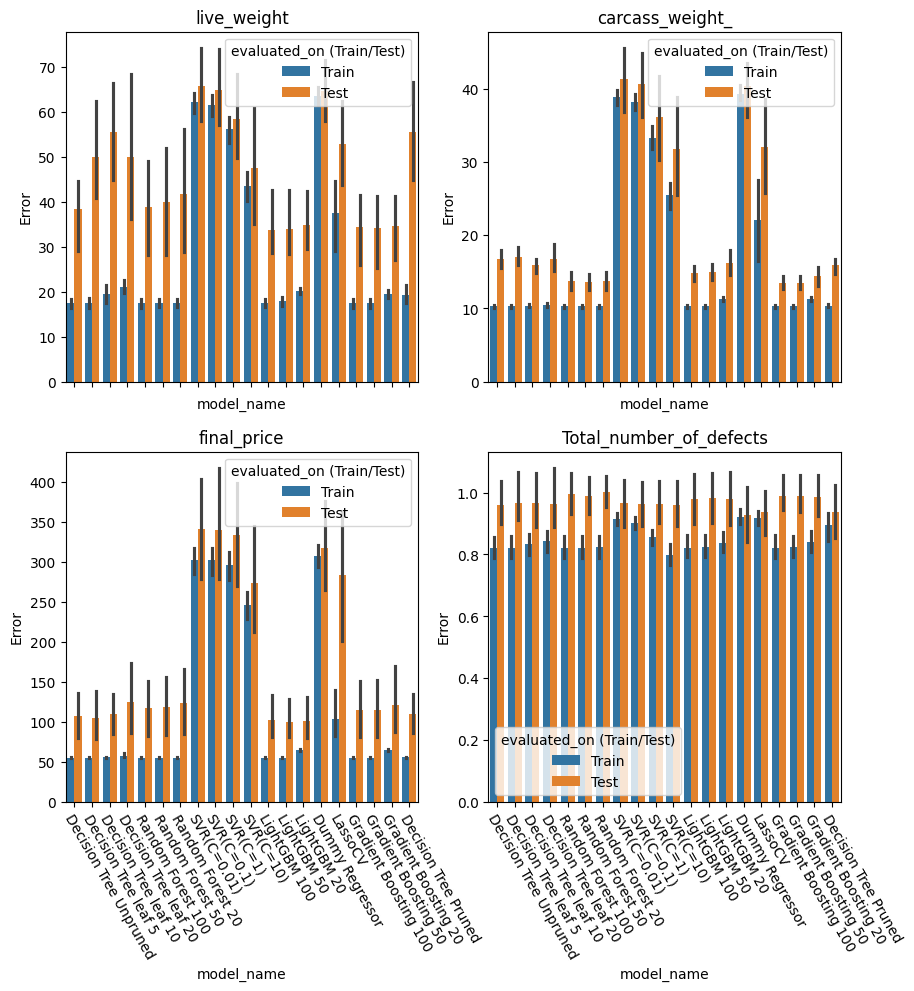

In [5]:
f, axs = plt.subplots(2, 2, sharey=False, figsize=(10, 10))

for i, target in enumerate(targets):
    target_data = df_21_mae[df_21_mae['target'] == target]
    
    ax = axs[i//2, i%2]
    sns.barplot(data=target_data, x='model_name', y='Error', hue='evaluated_on (Train/Test)', ax=ax, errorbar=("ci", 95))
    ax.set_title(target)
    
    if i // 2 == 1:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=300, ha='left', rotation_mode='anchor')
    else:
        ax.set_xticklabels([])

plt.savefig(f"../Picture/Result/Model Fitting Performance.pdf", format='pdf', bbox_inches='tight')
plt.show()

C:\Users\20514\AppData\Local\Temp\ipykernel_30540\1772169706.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=300, ha='left', rotation_mode='anchor')
C:\Users\20514\AppData\Local\Temp\ipykernel_30540\1772169706.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=300, ha='left', rotation_mode='anchor')


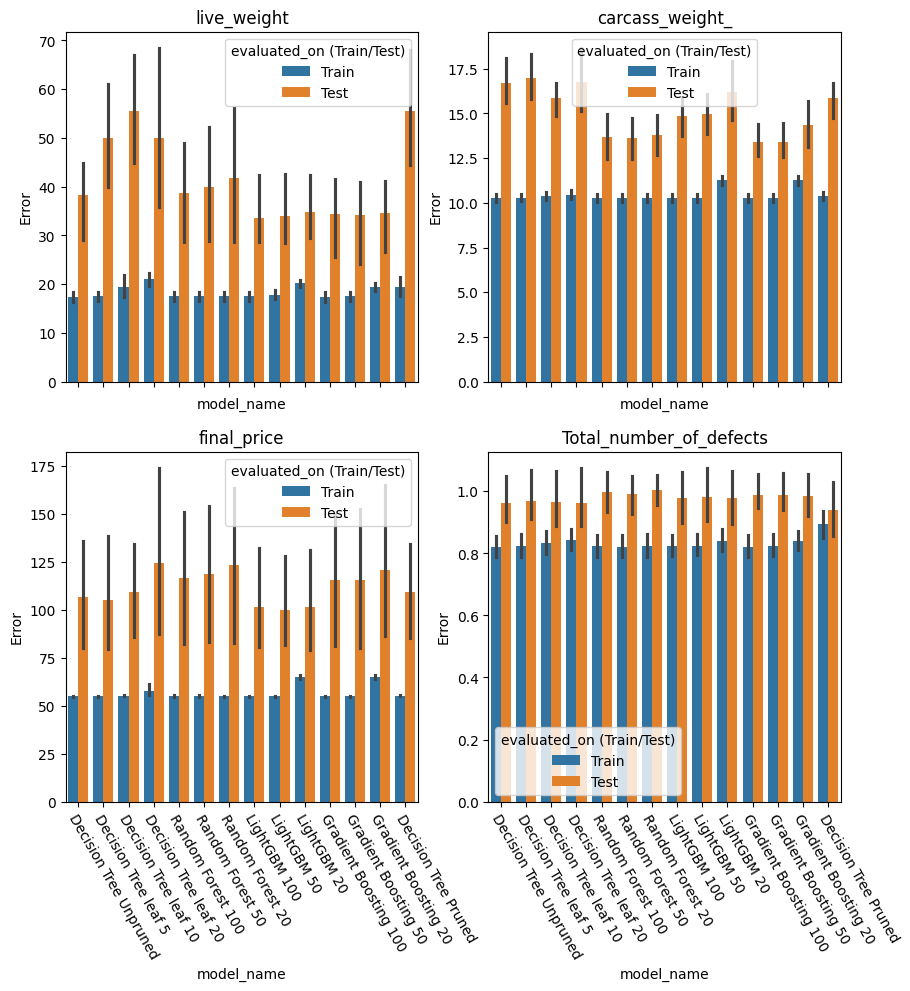

In [6]:
# Without SVR, LassoCV, Dummy Regressor
df_21_mae_clean = df_21_mae[~df_21_mae['model_name'].str.contains('SVR|LassoCV|Dummy', regex=True)]

f, axs = plt.subplots(2, 2, sharey=False, figsize=(10, 10))
for i, target in enumerate(targets):
    ax = axs[i//2, i%2]
    g = sns.barplot(df_21_mae_clean[df_21_mae_clean['target']==target], x='model_name', y='Error', hue='evaluated_on (Train/Test)', ax=ax, errorbar=("ci", 95))
    ax.set_title(target)
    
    if i // 2 == 1:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=300, ha='left', rotation_mode='anchor')
    else:
        ax.set_xticklabels([])

plt.savefig(f"../Picture/Result/Model Fitting Performance Cleaned.pdf", format='pdf', bbox_inches='tight')
plt.show()

## 2. Which model predicts the target best?(MAE)

C:\Users\20514\AppData\Local\Temp\ipykernel_30540\3833953281.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=300, ha='left', rotation_mode='anchor')
C:\Users\20514\AppData\Local\Temp\ipykernel_30540\3833953281.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=300, ha='left', rotation_mode='anchor')


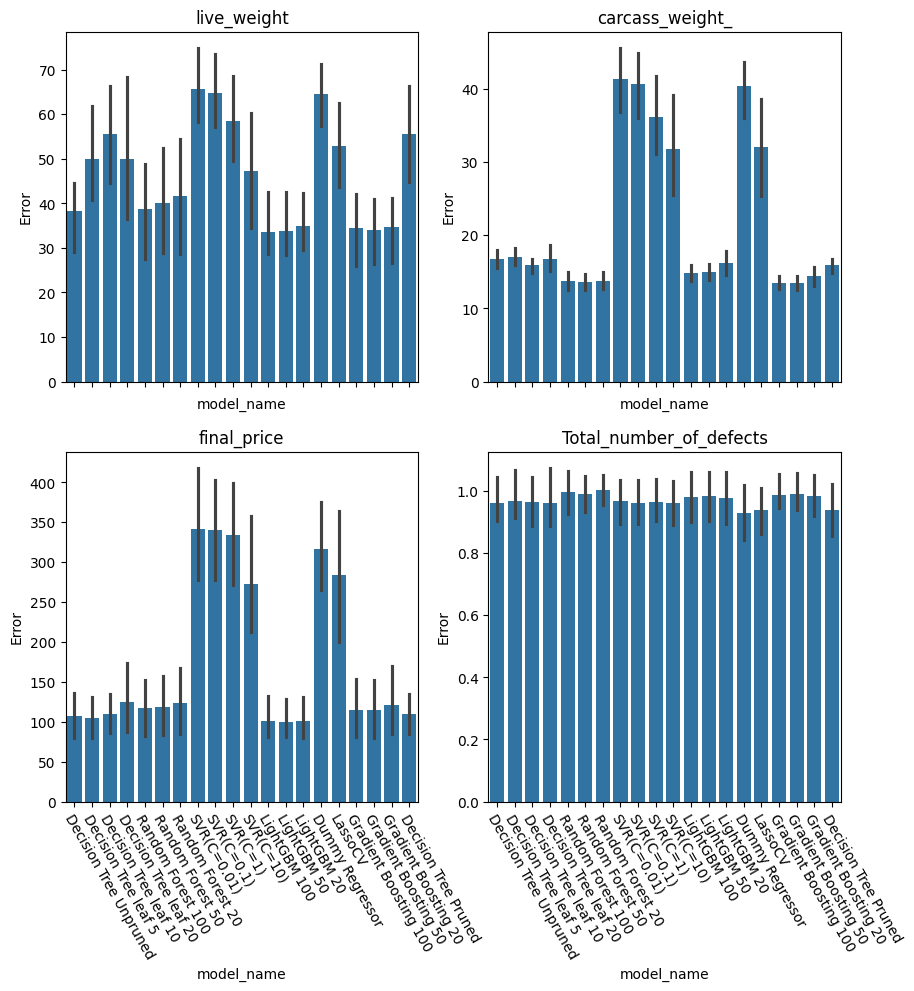

In [7]:
df_21_mae_test = df_21_mae[df_21_mae['evaluated_on (Train/Test)']=='Test']

f, axs = plt.subplots(2, 2, sharey=False, figsize=(10, 10))
for i, target in enumerate(targets):
    ax = axs[i//2, i%2]
    g = sns.barplot(df_21_mae_test[df_21_mae_test['target']==target], x='model_name', y='Error', ax=ax, errorbar=("ci", 95))
    ax.set_title(target)
    
    if i // 2 == 1:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=300, ha='left', rotation_mode='anchor')
    else:
        ax.set_xticklabels([])

plt.savefig(f"../Picture/Result/Model Prediction Performance.pdf", format='pdf', bbox_inches='tight')
plt.show()

C:\Users\20514\AppData\Local\Temp\ipykernel_30540\1427608517.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=300, ha='left', rotation_mode='anchor')
C:\Users\20514\AppData\Local\Temp\ipykernel_30540\1427608517.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=300, ha='left', rotation_mode='anchor')


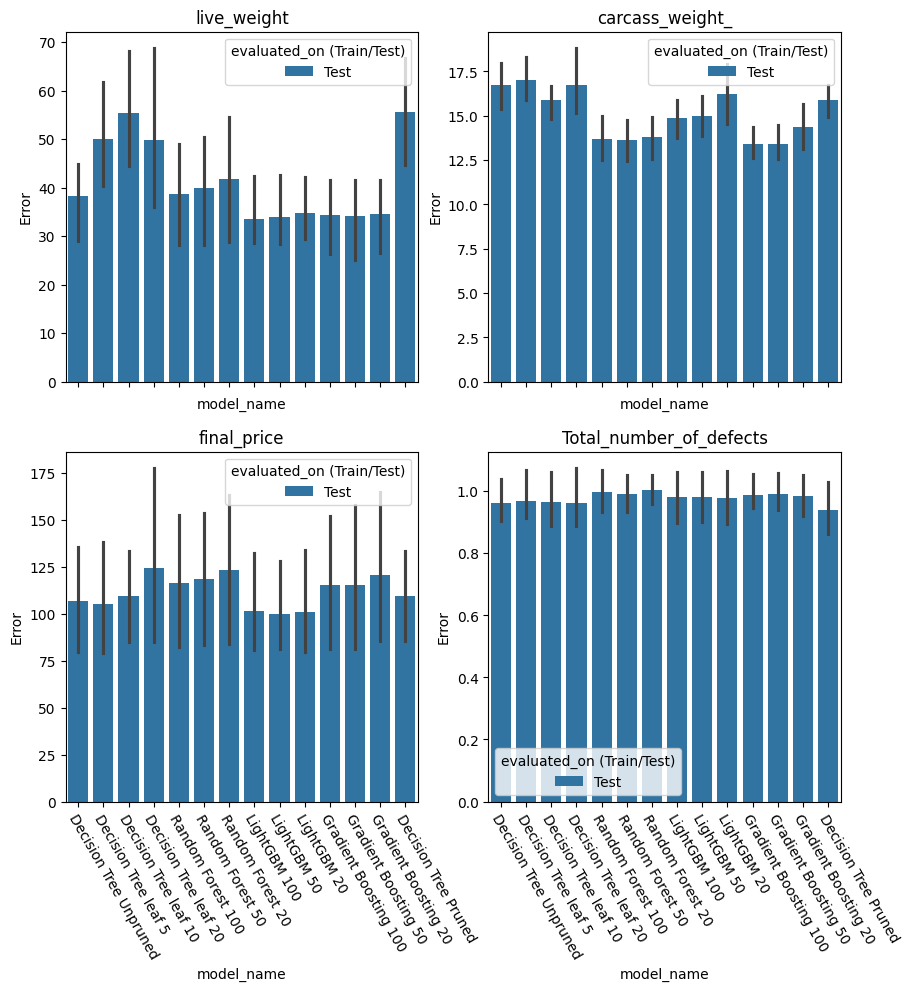

In [8]:
# Without SVR, LassoCV, Dummy Regressor
df_21_mae_test_clean = df_21_mae_test[~df_21_mae_test['model_name'].str.contains('SVR|LassoCV|Dummy', regex=True)]

f, axs = plt.subplots(2, 2, sharey=False, figsize=(10, 10))
for i, target in enumerate(targets):
    ax = axs[i//2, i%2]
    g = sns.barplot(df_21_mae_test_clean[df_21_mae_test_clean['target']==target], x='model_name', y='Error', hue='evaluated_on (Train/Test)', ax=ax, errorbar=("ci", 95))
    ax.set_title(target)
    
    if i // 2 == 1:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=300, ha='left', rotation_mode='anchor')
    else:
        ax.set_xticklabels([])

plt.savefig(f"../Picture/Result/Model Prediction Performance Cleaned.pdf", format='pdf', bbox_inches='tight')
plt.show()

## 3. Are differences between models statistically significant?

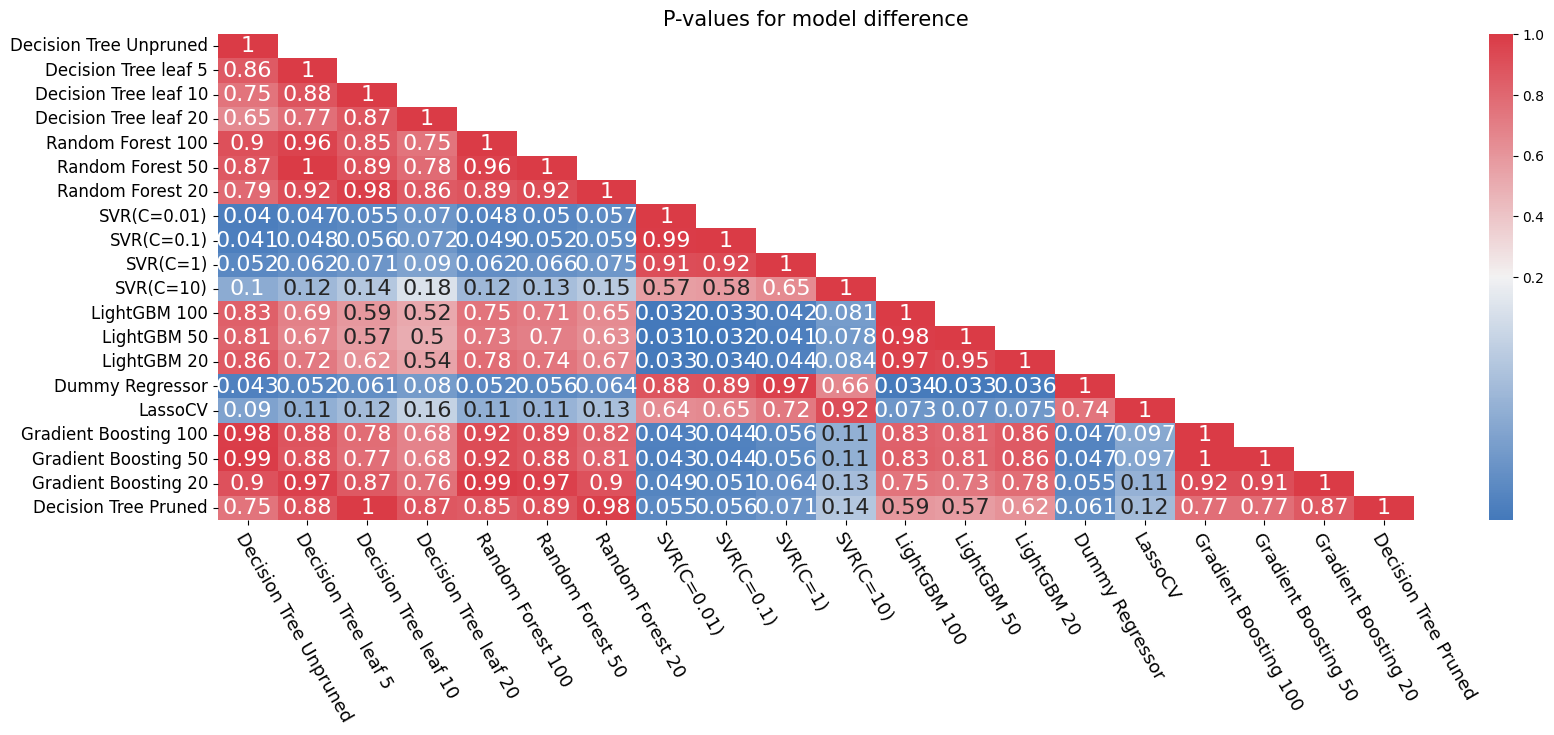

In [9]:
from matplotlib.colors import TwoSlopeNorm

def calculate_p_values(data, models, evaluated_on):
    p_values = np.zeros((len(models), len(models)))
    for i in range(len(models)):
        group1 = data[(data['model_name'] == models[i]) & (data['evaluated_on (Train/Test)'] == evaluated_on)]['Error']
        for j in range(i, len(models)):
            group2 = data[(data['model_name'] == models[j]) & (data['evaluated_on (Train/Test)'] == evaluated_on)]['Error']
            _, p_value = ttest_ind(group1, group2)
            p_values[i, j] = p_value
            p_values[j, i] = p_value
    
    return p_values

models = df_21_mae['model_name'].unique()

# Create subplots for each target
f = plt.subplots(1, figsize=(17, 7))

p_values = calculate_p_values(df_21_mae, models, 'Test')
threshold = 0.2

# Create a custom colormap
cmap = sns.diverging_palette(250, 10, as_cmap=True)

# Normalize the colormap to center at the threshold
norm = TwoSlopeNorm(vmin=p_values.min(), vcenter=threshold, vmax=p_values.max())

mask = np.triu(np.ones_like(p_values, dtype=bool), k=1)

# Plot the heatmap with the mask
g = sns.heatmap(p_values, annot=True, cmap=cmap, norm=norm, xticklabels=models, yticklabels=models, cbar=True, mask=mask, annot_kws={"size": 16})

g.set_title('P-values for model difference', fontsize=15)
plt.setp(g.get_xticklabels(), rotation=300, ha='left', rotation_mode='anchor')

plt.tight_layout()
plt.xticks(fontsize=13)
plt.yticks(fontsize=12)
plt.savefig(f"../Picture/Result/Model Differences.pdf", format='pdf', bbox_inches='tight')
plt.show()

## 4. Which target is the easiest to predict?(MAPE)

In [4]:
df_21_mape = df_21[df_21['measure (MAE/MAPE)'] == 'MAPE']
df_21_mape_test = df_21_mape[df_21_mape['evaluated_on (Train/Test)']=='Test']
print(df_21_mape)

                  model_name                   target  max_lag  \
162   Decision Tree Unpruned              live_weight       21   
163   Decision Tree Unpruned              live_weight       21   
166   Decision Tree Unpruned              live_weight       21   
167   Decision Tree Unpruned              live_weight       21   
170   Decision Tree Unpruned              live_weight       21   
...                      ...                      ...      ...   
6311    Decision Tree Pruned  Total_number_of_defects       21   
6314    Decision Tree Pruned  Total_number_of_defects       21   
6315    Decision Tree Pruned  Total_number_of_defects       21   
6318    Decision Tree Pruned  Total_number_of_defects       21   
6319    Decision Tree Pruned  Total_number_of_defects       21   

     measure (MAE/MAPE)  Cross-validation evaluated_on (Train/Test)  \
162                MAPE                 1                     Train   
163                MAPE                 1                      Te

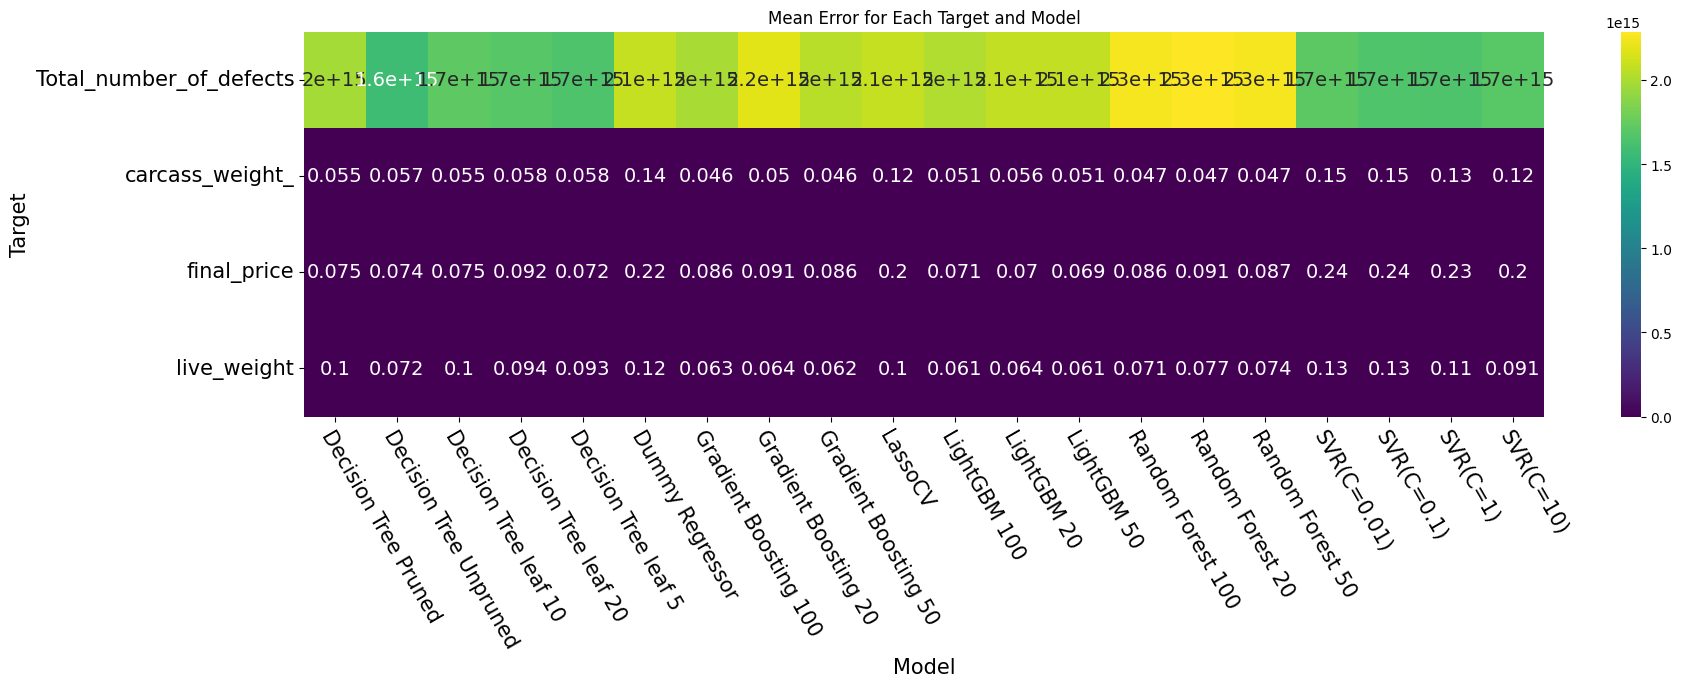

In [5]:
# Grouping and Calculating Mean Errors
mean_errors = df_21_mape_test.groupby(['target', 'model_name'])['Error'].mean().unstack()
# Plot mean errors using a heatmap
plt.figure(figsize=(20, 5))
sns.heatmap(mean_errors, annot=True, cmap='viridis', cbar=True, annot_kws={"size": 14})
plt.title('Mean Error for Each Target and Model')
plt.ylabel('Target', fontsize=15)
plt.xlabel('Model', fontsize=15)
plt.xticks(rotation=300, ha='left', rotation_mode='anchor', fontsize=15)
plt.yticks(fontsize=15)
plt.savefig(f"../Picture/Result/Target Predict.pdf", format='pdf', bbox_inches='tight')
plt.show()

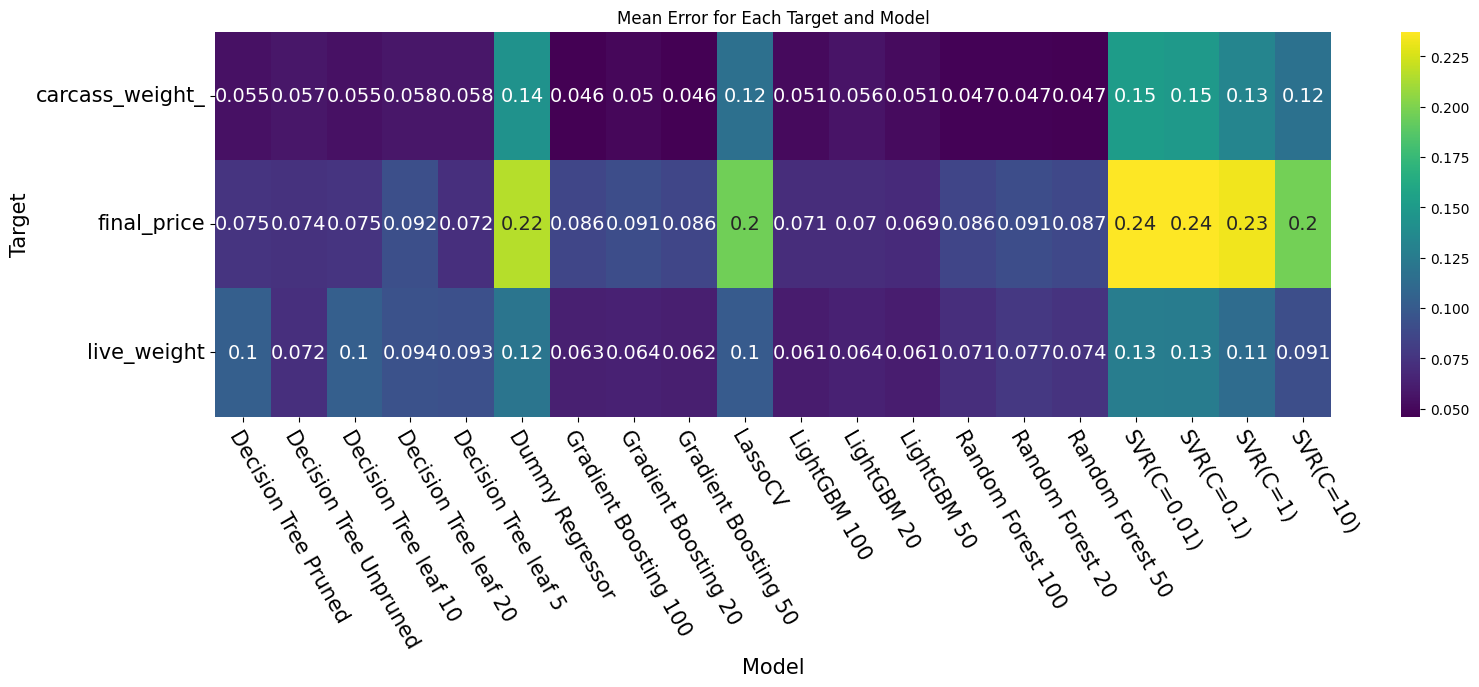

In [12]:
# Delete Total number of defects
mean_errors = mean_errors.drop('Total_number_of_defects')
# Plot mean errors using a heatmap
plt.figure(figsize=(18, 5))
sns.heatmap(mean_errors, annot=True, cmap='viridis', cbar=True, annot_kws={"size": 14})
plt.title('Mean Absolute Percentage Error for Each Target and Model')
plt.ylabel('Target', fontsize=15)
plt.xlabel('Model', fontsize=15)
plt.xticks(rotation=300, ha='left', rotation_mode='anchor', fontsize=15)
plt.yticks(fontsize=15, rotation_mode='anchor', rotation=0)
plt.savefig(f"../Picture/Result/Target Predict Cleaned.pdf", format='pdf', bbox_inches='tight')
plt.show()